In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression

In [127]:
df=pd.read_csv('loan_data.csv')
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [128]:
x=df.drop(columns='loan_status')
y=df.loan_status

In [129]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [130]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns
num_cols

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object')

<Axes: >

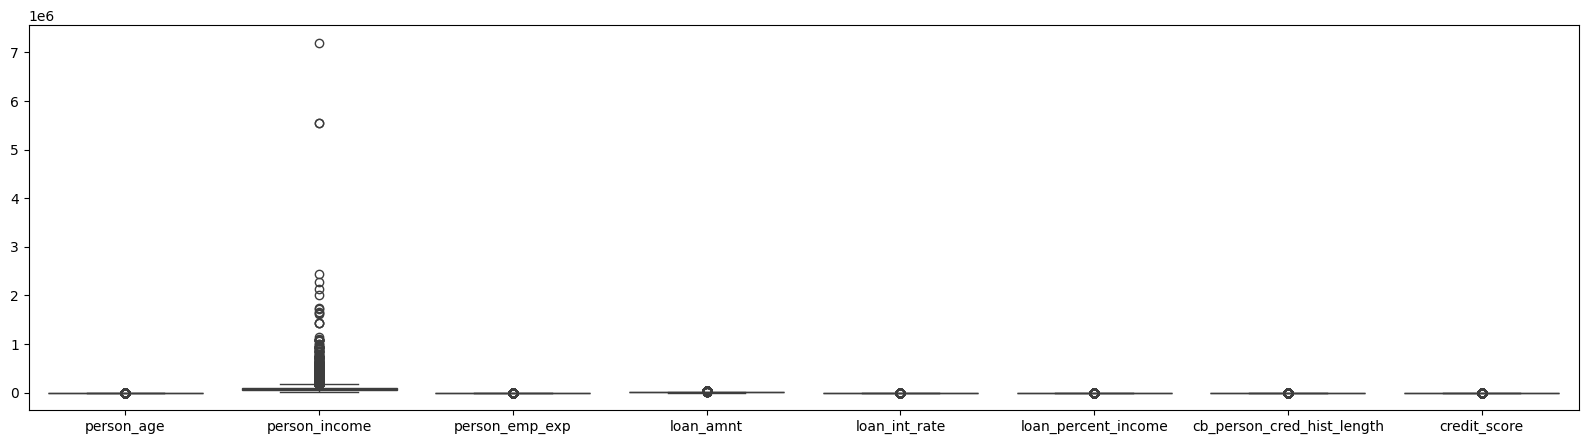

In [131]:
plt.figure(figsize=(20,5))
sns.boxplot(df[num_cols])

- As we can see above we are having outliers, so we need to use Standardardization techniques.
- As we can see in person_income columns there are more outliers so here we need to use RobustScaler.

In [132]:
df.corr(numeric_only=True)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
person_age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432,-0.021476
person_income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919,-0.135808
person_emp_exp,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196,-0.020481
loan_amnt,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074,0.107714
loan_int_rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498,0.332005
loan_percent_income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483,0.384880
cb_person_cred_hist_length,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.014851
credit_score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.007647
loan_status,-0.021476,-0.135808,-0.020481,0.107714,0.332005,0.384880,-0.014851,-0.007647,1.000000


- Applying scaling techniques

In [133]:
scale=RobustScaler()
xtrain[num_cols]=scale.fit_transform(xtrain[num_cols])
xtest[num_cols]=scale.transform(xtest[num_cols])

In [134]:
xtrain[obj_cols].nunique()

person_gender                     2
person_education                  5
person_home_ownership             4
loan_intent                       6
previous_loan_defaults_on_file    2
dtype: int64

- As there are less unique values <=10, so here we can use OneHotEncoder technique

In [135]:
encoder=OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [136]:
values=encoder.fit_transform(xtrain[obj_cols])
cols=encoder.get_feature_names_out()

In [137]:
xtrain[cols]=values
xtrain.drop(columns=obj_cols,inplace=True)
xtrain

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_female,person_gender_male,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
25180,1.333333,0.621771,1.000000,0.965517,0.386517,0.250000,1.0,-0.132353,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
12555,-0.166667,0.120777,-0.142857,0.551724,0.191011,0.333333,0.0,0.279412,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
29153,2.500000,5.265159,2.000000,2.206897,-0.143820,-0.416667,1.4,0.632353,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
23838,0.166667,0.559271,0.000000,0.220690,1.377528,-0.166667,0.6,0.014706,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
35686,0.166667,0.366411,0.428571,-0.129793,0.440449,-0.333333,-0.2,0.970588,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.000000,0.440142,0.285714,0.362069,-1.119101,0.000000,0.0,-1.191176,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
44732,-0.166667,-0.666014,-0.142857,-0.292966,0.152809,0.416667,0.0,0.102941,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
38158,1.166667,-0.180825,0.714286,0.373379,-0.060674,0.500000,1.0,0.176471,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
860,0.000000,2.297872,0.285714,1.655172,1.568539,-0.083333,-0.2,-0.529412,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [138]:
val=encoder.transform(xtest[obj_cols])
col=encoder.get_feature_names_out()

In [139]:
xtest[col]=val
xtest.drop(columns=obj_cols,inplace=True)
xtest

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_female,person_gender_male,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
37979,1.000000,0.613528,0.857143,-0.068966,-1.116854,-0.333333,1.2,-0.573529,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9911,-0.333333,-0.211303,0.285714,0.137931,0.107865,0.333333,0.0,0.102941,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
43386,-0.666667,-0.613961,-0.571429,-0.413793,0.869663,0.083333,0.0,1.044118,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
13822,-0.500000,-0.559435,-0.428571,-0.413793,0.669663,0.083333,-0.2,-0.632353,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
44810,2.666667,0.018175,2.285714,0.275862,0.988764,0.250000,1.4,-0.794118,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14572,-0.833333,1.362382,-0.571429,0.827586,-0.229213,-0.083333,-0.4,0.205882,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
30384,2.166667,-0.107218,1.857143,-0.175862,1.222472,-0.083333,1.4,-0.500000,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
36665,-0.333333,0.244356,-0.428571,0.827586,0.143820,0.500000,-0.2,-0.382353,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
30569,2.000000,-0.617176,1.714286,0.000000,0.000000,0.833333,2.0,0.808824,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [140]:
model=LogisticRegression()

In [141]:
model.fit(xtrain,ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'
